# 01 — Domain-gap evidence: Day vs. Night on the synthetic corridor scene

This notebook reproduces this project's central measured finding: a detector trained only
on **Day** (clean daylight, close standoff) imagery loses most or all of its accuracy on
**Night** (low light, long standoff, oblique angle) imagery of the *same* underlying scene,
and shows what recovers it. See `docs/METHODOLOGY_AND_LIMITATIONS.md#domain-gap-day-vs-night`
for the full write-up this notebook backs.

It imports the actual application code (`infrastructure_overwatch.synthetic`,
`infrastructure_overwatch.detectors.grid_cnn`) rather than redefining anything — if you
change the detector or renderer in `src/`, re-running this notebook re-measures the claim.

In [1]:
from pathlib import Path
import sys
HERE = Path.cwd().resolve()
ROOT = HERE.parent if HERE.name == "notebooks" else HERE
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))
print("Project root:", ROOT)

Project root: C:\dev\infrastructure-overwatch


In [2]:
import time
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from infrastructure_overwatch.synthetic import GRID, IMG_SIZE, N_SYNTHETIC_CLASSES, SyntheticCorridorDataset
from infrastructure_overwatch.detectors.grid_cnn import GridDetector, evaluate_grid_detector, train_grid_detector

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Train on Day only, then measure both domains

In [3]:
day_train_ds = SyntheticCorridorDataset(800, domain="day", seed=1)
day_val_ds = SyntheticCorridorDataset(200, domain="day", seed=2)
night_val_ds = SyntheticCorridorDataset(200, domain="night", seed=3)
day_train_loader = DataLoader(day_train_ds, batch_size=32, shuffle=True)

baseline_model = GridDetector(n_classes=N_SYNTHETIC_CLASSES, grid_h=GRID, grid_w=GRID)
t0 = time.time()
train_grid_detector(baseline_model, day_train_loader, epochs=20, device=device)
print(f"done in {time.time()-t0:.1f}s")

  epoch  1/20  loss 1.4105


  epoch  5/20  loss 0.2915


  epoch 10/20  loss 0.1363


  epoch 15/20  loss 0.0756


  epoch 20/20  loss 0.0484
done in 60.2s


Day   val -> precision 0.89  recall 0.84  F1 0.86
Night val -> precision 0.00  recall 0.00  F1 0.00


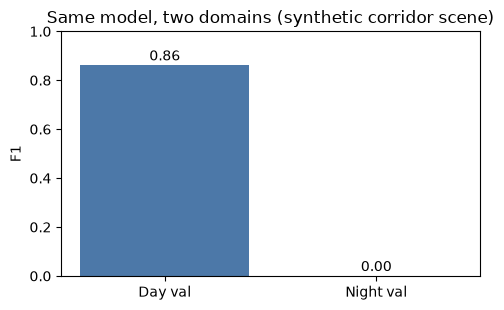

In [4]:
day_score = evaluate_grid_detector(baseline_model, day_val_ds, IMG_SIZE, IMG_SIZE, device=device)
night_score = evaluate_grid_detector(baseline_model, night_val_ds, IMG_SIZE, IMG_SIZE, device=device)
print(f"Day   val -> precision {day_score.precision:.2f}  recall {day_score.recall:.2f}  F1 {day_score.f1:.2f}")
print(f"Night val -> precision {night_score.precision:.2f}  recall {night_score.recall:.2f}  F1 {night_score.f1:.2f}")

fig, ax = plt.subplots(figsize=(5, 3.2))
bars = ax.bar(["Day val", "Night val"], [day_score.f1, night_score.f1], color=["#4C78A8", "#E45756"])
ax.set_ylim(0, 1.0)
ax.set_ylabel("F1")
ax.set_title("Same model, two domains (synthetic corridor scene)")
for b, v in zip(bars, [day_score.f1, night_score.f1], strict=True):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()

## Two remedies, and what each costs

- **Domain randomization** — train directly on Night-style rendering, reseeding every
  epoch (`fresh=True`), using no real Night-domain labels.
- **Fine-tuning** — start from the Day-trained weights, fine-tune on a small, fixed batch
  of Night-style samples, simulating "a field team sent back a small batch of labeled
  night frames."

Night val, Day-only baseline:     F1 0.00
Night val, domain randomization:  F1 0.50
Night val, fine-tuned (100 imgs): F1 0.43


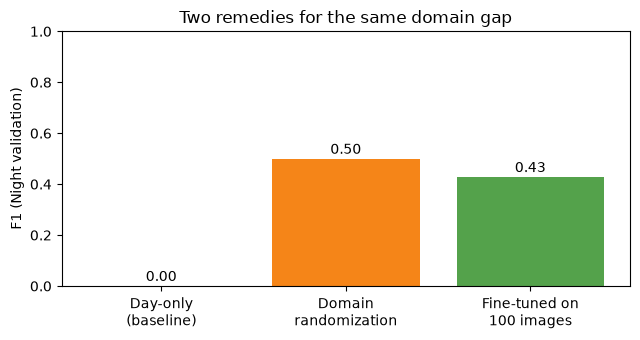

In [5]:
import copy

# Remedy A: domain randomization
augmented_train_ds = SyntheticCorridorDataset(500, domain="night", fresh=True)
augmented_loader = DataLoader(augmented_train_ds, batch_size=32, shuffle=True)
augmented_model = GridDetector(n_classes=N_SYNTHETIC_CLASSES, grid_h=GRID, grid_w=GRID)
train_grid_detector(augmented_model, augmented_loader, epochs=20, device=device, quiet=True)
augmented_score = evaluate_grid_detector(augmented_model, night_val_ds, IMG_SIZE, IMG_SIZE, device=device)

# Remedy B: limited fine-tuning on a small Night-style batch
night_small_train_ds = SyntheticCorridorDataset(100, domain="night", seed=99)
night_small_loader = DataLoader(night_small_train_ds, batch_size=16, shuffle=True)
finetuned_model = copy.deepcopy(baseline_model)
train_grid_detector(finetuned_model, night_small_loader, epochs=20, lr=2e-4, device=device, quiet=True)
finetuned_score = evaluate_grid_detector(finetuned_model, night_val_ds, IMG_SIZE, IMG_SIZE, device=device)

print(f"Night val, Day-only baseline:     F1 {night_score.f1:.2f}")
print(f"Night val, domain randomization:  F1 {augmented_score.f1:.2f}")
print(f"Night val, fine-tuned (100 imgs): F1 {finetuned_score.f1:.2f}")

fig, ax = plt.subplots(figsize=(6.5, 3.5))
names = ["Day-only\n(baseline)", "Domain\nrandomization", "Fine-tuned on\n100 images"]
f1s = [night_score.f1, augmented_score.f1, finetuned_score.f1]
bars = ax.bar(names, f1s, color=["#E45756", "#F58518", "#54A24B"])
ax.set_ylim(0, 1.0)
ax.set_ylabel("F1 (Night validation)")
ax.set_title("Two remedies for the same domain gap")
for b, v in zip(bars, f1s, strict=True):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()

## Takeaway

The collapse from Day-only training to Night evaluation, and the partial recovery from
either remedy, is the mechanism `docs/METHODOLOGY_AND_LIMITATIONS.md` and
`docs/USER_MANUAL.md` both build on: this system is measurably worse in degraded
conditions, and a missing alert at night is not evidence nothing is there. See
`02_real_data_validation.ipynb` for the same mechanism measured independently on real
drone footage.